In [9]:
#@title Do the imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#@title Load the data

df = pd.read_csv('student_data.csv')
sns.set(style="whitegrid")

display(df)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


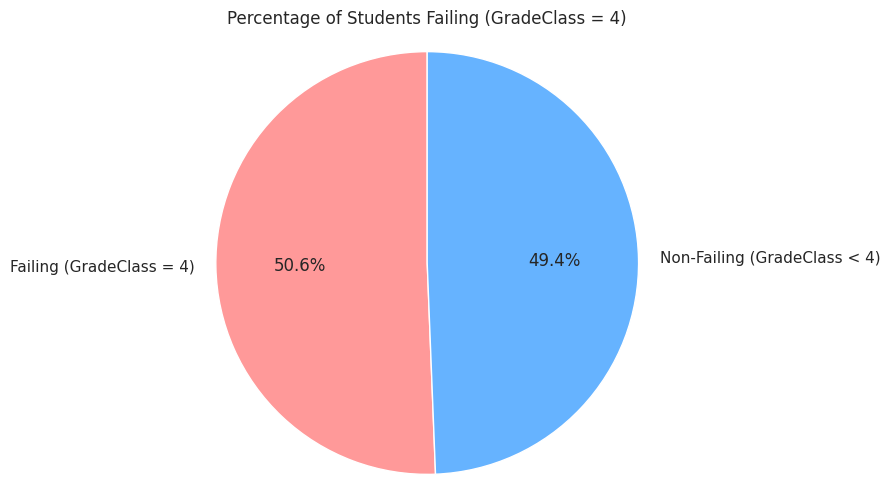

In [ ]:
#@title Percentage of Students Failing (GradeClass = 4)
total_students = len(df)
failing_students = len(df[df['GradeClass'] == 4])
failing_percentage = (failing_students / total_students) * 100


# Visualization: Pie chart
plt.figure(figsize=(6, 6))
labels = ['Failing (GradeClass = 4)', 'Non-Failing (GradeClass < 4)']
sizes = [failing_percentage, 100 - failing_percentage]
colors = ['#ff9999', '#66b3ff']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Students Failing (GradeClass = 4)')
plt.axis('equal')
plt.show()

<ipython-input-15-2bc3b81e059d>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Passing Students', 'Failing Students'],


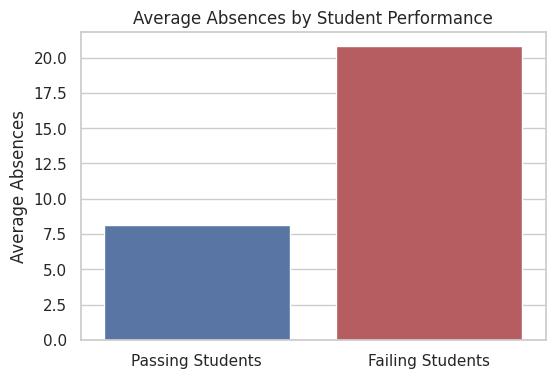

In [ ]:
#@title Average number of absences among students
avg_absences_passing = df[df['GradeClass'] < 4]['Absences'].mean()
avg_absences_failing = df[df['GradeClass'] == 4]['Absences'].mean()

# Combined bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=['Passing Students', 'Failing Students'],
            y=[avg_absences_passing, avg_absences_failing],
            palette=['#4C72B0', '#C44E52'])  # blue for passing, red for failing
plt.title('Average Absences by Student Performance')
plt.ylabel('Average Absences')
plt.show()


Failing students with low parental support: 400
Failing students with high parental support: 811


<ipython-input-21-0998605df2d2>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Low Support (0-1)', 'High Support (2-4)'], y=[low_support_failing, high_support_failing], palette='Blues')


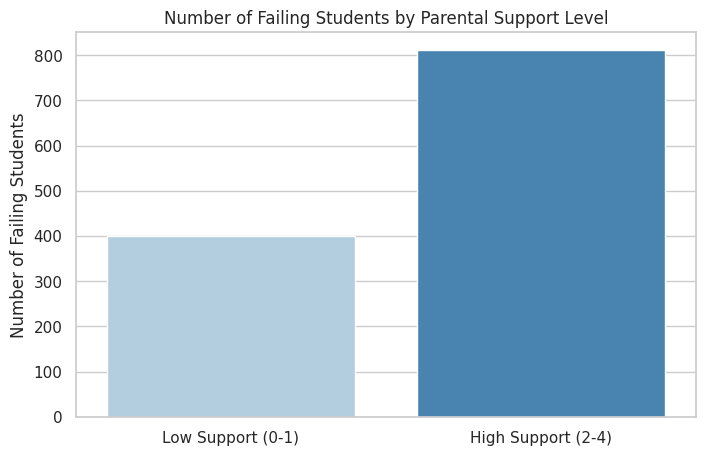

In [ ]:
#@title Number of Failing Students by Parental Support Level
low_support = df[df['ParentalSupport'].isin([0, 1])]
high_support = df[df['ParentalSupport'].isin([2, 3, 4])]
low_support_failing = len(low_support[low_support['GradeClass'] == 4])
high_support_failing = len(high_support[high_support['GradeClass'] == 4])

print(f"Failing students with low parental support: {low_support_failing}")
print(f"Failing students with high parental support: {high_support_failing}")

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['Low Support (0-1)', 'High Support (2-4)'], y=[low_support_failing, high_support_failing], palette='Blues')
plt.title('Number of Failing Students by Parental Support Level')
plt.ylabel('Number of Failing Students')
plt.show()

Average weekly study time for failing students: 9.18 hours
Median weekly study time for failing students: 8.85 hours


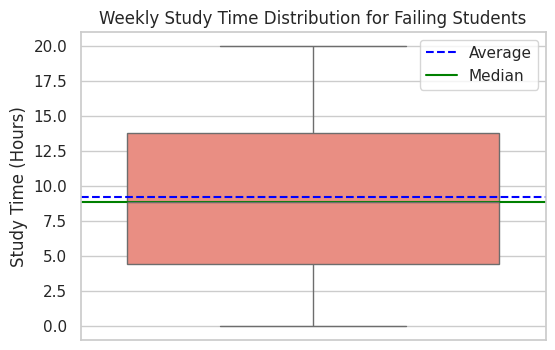

In [12]:
#@title Weekly Study Time Distribution for Failing Students

# Filter data for failing students
study_time_failing = df[df['GradeClass'] == 4]['StudyTimeWeekly']
avg_study_time_failing = study_time_failing.mean()
median_study_time_failing = study_time_failing.median()

print(f"Average weekly study time for failing students: {avg_study_time_failing:.2f} hours")
print(f"Median weekly study time for failing students: {median_study_time_failing:.2f} hours")

# Visualization: Box plot with average and median lines
plt.figure(figsize=(6, 4))
sns.boxplot(y=study_time_failing, color='salmon')
plt.axhline(avg_study_time_failing, color='blue', linestyle='--', label='Average')
plt.axhline(median_study_time_failing, color='green', linestyle='-', label='Median')
plt.title('Weekly Study Time Distribution for Failing Students')
plt.ylabel('Study Time (Hours)')
plt.legend()
plt.show()


Average GPA for failing students with tutoring: 1.34
Average GPA for failing students without tutoring: 1.16


<ipython-input-29-23b1e4683259>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['With Tutoring', 'Without Tutoring'], y=[tutoring_failing_gpa, no_tutoring_failing_gpa], palette='Greens')


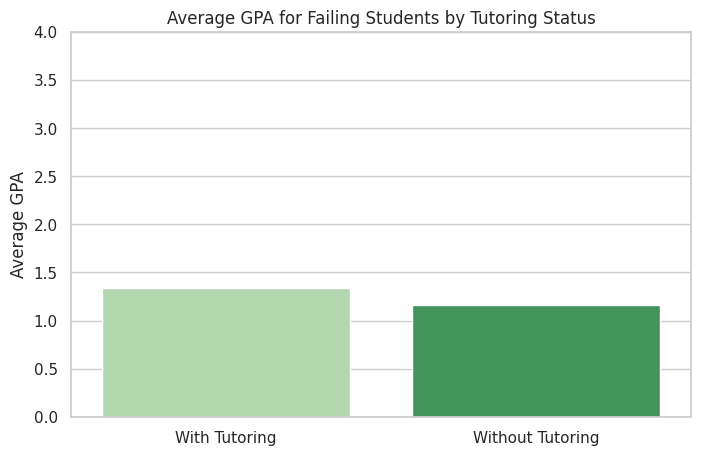

In [29]:
# @title Average GPA for failing students (GradeClass == 4), split by tutoring status
failing_students = df[df['GradeClass'] == 4]

tutoring_failing_gpa = failing_students[failing_students['Tutoring'] == 1]['GPA'].mean()
no_tutoring_failing_gpa = failing_students[failing_students['Tutoring'] == 0]['GPA'].mean()

print(f"Average GPA for failing students with tutoring: {tutoring_failing_gpa:.2f}")
print(f"Average GPA for failing students without tutoring: {no_tutoring_failing_gpa:.2f}")

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['With Tutoring', 'Without Tutoring'], y=[tutoring_failing_gpa, no_tutoring_failing_gpa], palette='Greens')
plt.title('Average GPA for Failing Students by Tutoring Status')
plt.ylabel('Average GPA')
plt.ylim(0, 4)
plt.show()

Failure rate without extracurriculars: 52.41%
Failure rate with extracurriculars: 47.76%


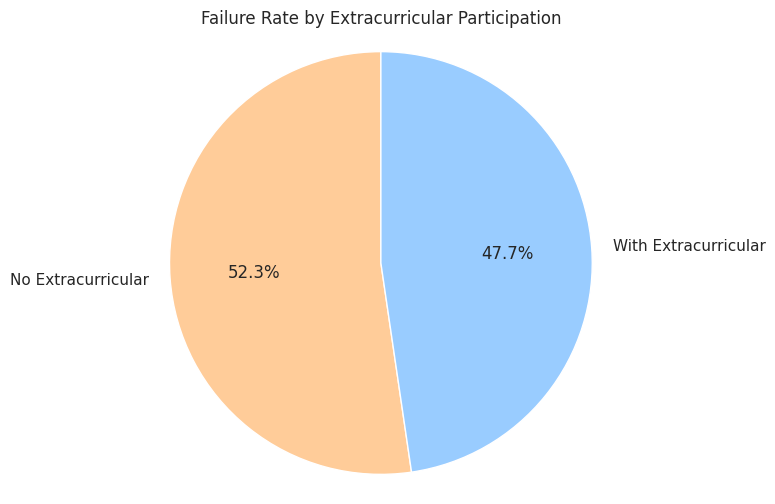

In [30]:
#@title Failure Rate by Extracurricular Participation
no_extracurricular_failing = len(df[(df['Extracurricular'] == 0) & (df['GradeClass'] == 4)]) / len(df[df['Extracurricular'] == 0]) * 100
extracurricular_failing = len(df[(df['Extracurricular'] == 1) & (df['GradeClass'] == 4)]) / len(df[df['Extracurricular'] == 1]) * 100

print(f"Failure rate without extracurriculars: {no_extracurricular_failing:.2f}%")
print(f"Failure rate with extracurriculars: {extracurricular_failing:.2f}%")

# Visualization: Pie chart
plt.figure(figsize=(6, 6))
labels = ['No Extracurricular', 'With Extracurricular']
sizes = [no_extracurricular_failing, extracurricular_failing]
colors = ['#ffcc99', '#99ccff']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Failure Rate by Extracurricular Participation')
plt.axis('equal')
plt.show()

Failure rate for males: 49.74%
Failure rate for females: 51.47%


<ipython-input-31-31ad375e487b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Male', 'Female'], y=[male_failing, female_failing], palette='Purples')


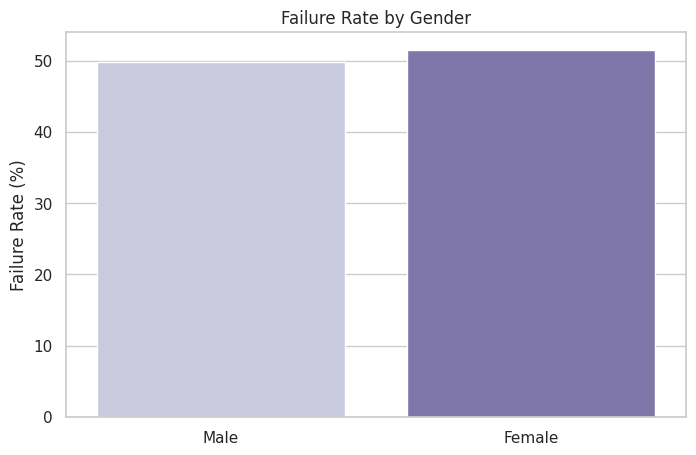

In [31]:
#@title Failure Rate by Gender
male_failing = len(df[(df['Gender'] == 0) & (df['GradeClass'] == 4)]) / len(df[df['Gender'] == 0]) * 100
female_failing = len(df[(df['Gender'] == 1) & (df['GradeClass'] == 4)]) / len(df[df['Gender'] == 1]) * 100

print(f"Failure rate for males: {male_failing:.2f}%")
print(f"Failure rate for females: {female_failing:.2f}%")

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['Male', 'Female'], y=[male_failing, female_failing], palette='Purples')
plt.title('Failure Rate by Gender')
plt.ylabel('Failure Rate (%)')
plt.show()

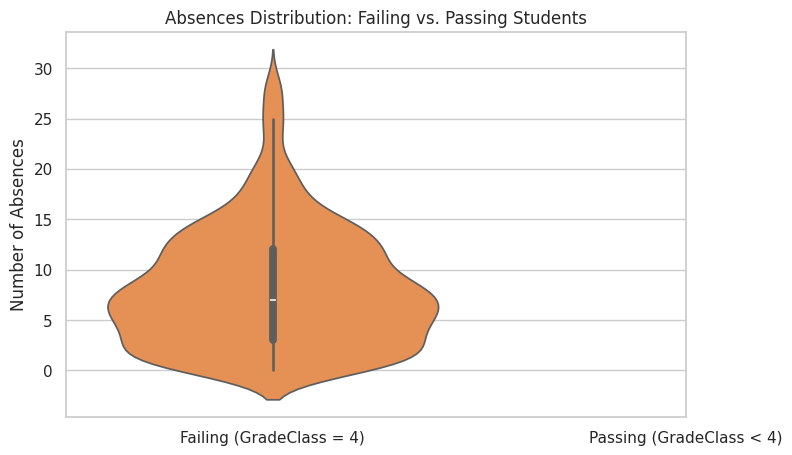

In [32]:
#@title Absences Distribution: Failing vs. Passing Students
failing_absences = df[df['GradeClass'] == 4]['Absences']
passing_absences = df[df['GradeClass'] < 4]['Absences']

# Visualization: Violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=[failing_absences, passing_absences], palette='Oranges')
plt.xticks([0, 1], ['Failing (GradeClass = 4)', 'Passing (GradeClass < 4)'])
plt.title('Absences Distribution: Failing vs. Passing Students')
plt.ylabel('Number of Absences')
plt.show()

<ipython-input-33-25eb2fa7d57d>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rates = df.groupby('AbsenceBins')['GradeClass'].apply(lambda x: (x == 4).mean() * 100)


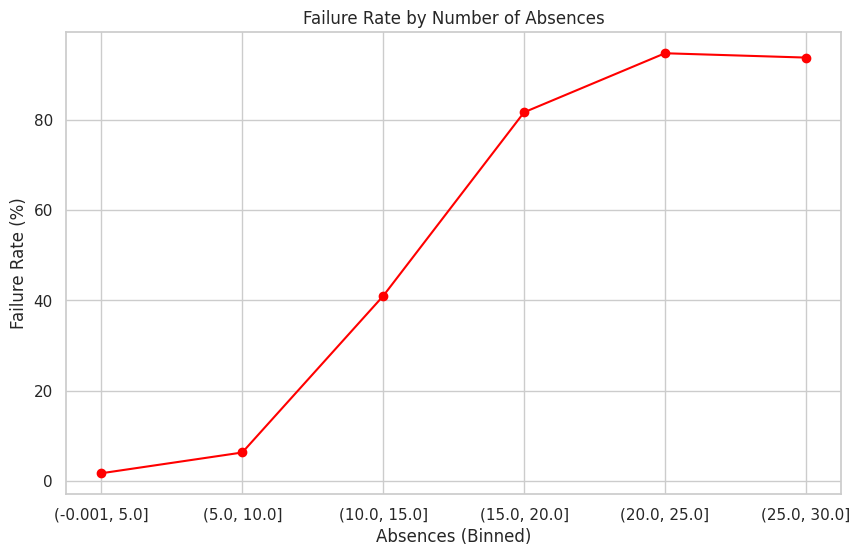

In [33]:
#@title Failure Rate by Number of Absences
df['AbsenceBins'] = pd.cut(df['Absences'], bins=[0, 5, 10, 15, 20, 25, 30], include_lowest=True)
failure_rates = df.groupby('AbsenceBins')['GradeClass'].apply(lambda x: (x == 4).mean() * 100)

# Visualization: Line plot
plt.figure(figsize=(10, 6))
failure_rates.plot(kind='line', marker='o', color='red')
plt.title('Failure Rate by Number of Absences')
plt.xlabel('Absences (Binned)')
plt.ylabel('Failure Rate (%)')
plt.grid(True)
plt.show()

<ipython-input-30-dadb2fc93256>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_by_parental_edu.index, y=failure_by_parental_edu.values, palette='Blues')


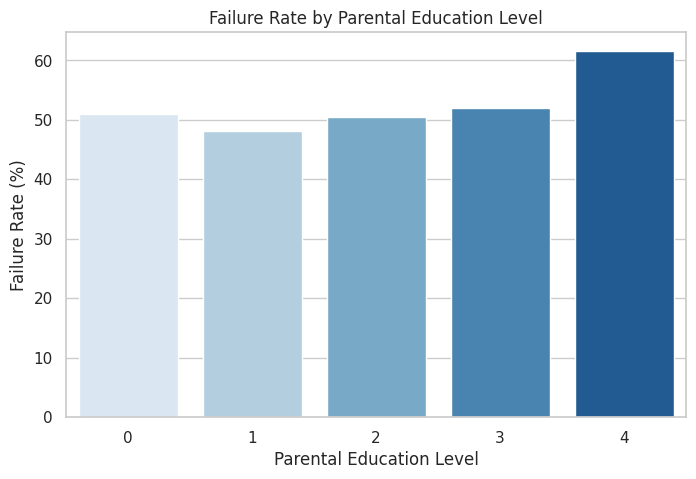

In [ ]:
#@title Failure Rate by Parental Education Level
failure_by_parental_edu = df.groupby('ParentalEducation')['GradeClass'].apply(lambda x: (x == 4).mean() * 100)

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=failure_by_parental_edu.index, y=failure_by_parental_edu.values, palette='Blues')
plt.title('Failure Rate by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Failure Rate (%)')
plt.show()

<ipython-input-31-f29a008e74ab>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df, palette='Set2')


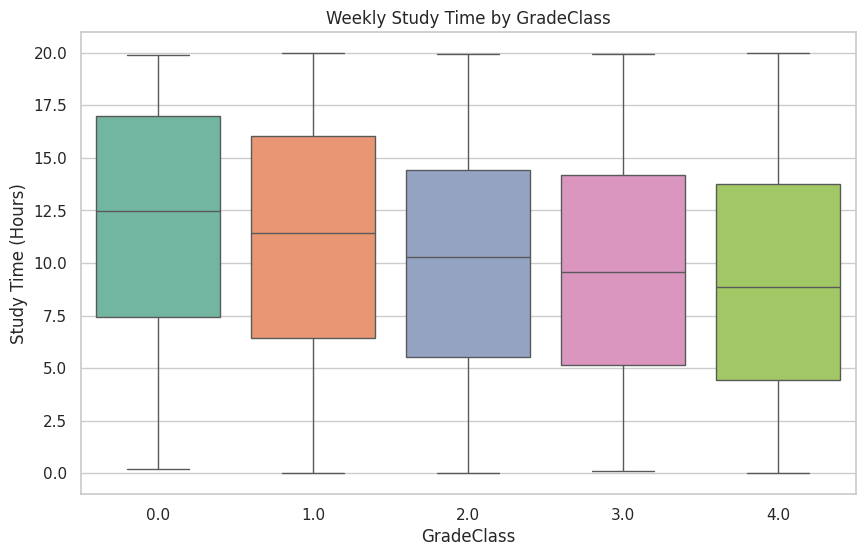

In [ ]:
#@title Weekly Study Time by GradeClass
plt.figure(figsize=(10, 6))
sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df, palette='Set2')
plt.title('Weekly Study Time by GradeClass')
plt.xlabel('GradeClass')
plt.ylabel('Study Time (Hours)')
plt.show()

Failure rate for age 15: 51.11%
Failure rate for age 18: 51.72%


<ipython-input-33-446660c4f24e>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Age 15', 'Age 18'], y=[age_15_failing, age_18_failing], palette='Greys')


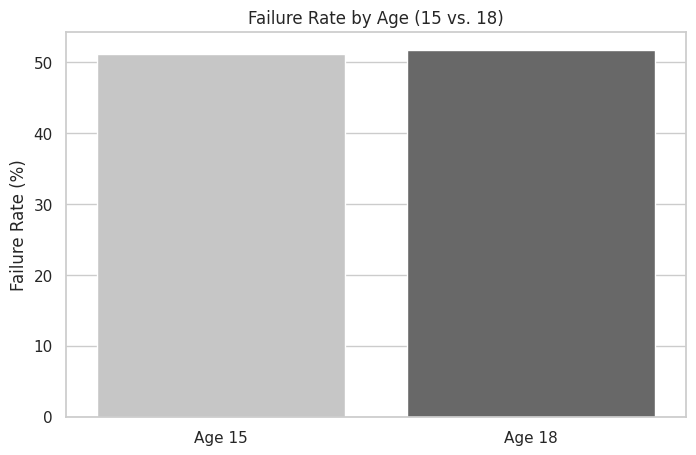

In [ ]:
#@title Failure Rate by Age (15 vs. 18)
age_15_failing = len(df[(df['Age'] == 15) & (df['GradeClass'] == 4)]) / len(df[df['Age'] == 15]) * 100
age_18_failing = len(df[(df['Age'] == 18) & (df['GradeClass'] == 4)]) / len(df[df['Age'] == 18]) * 100

print(f"Failure rate for age 15: {age_15_failing:.2f}%")
print(f"Failure rate for age 18: {age_18_failing:.2f}%")

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['Age 15', 'Age 18'], y=[age_15_failing, age_18_failing], palette='Greys')
plt.title('Failure Rate by Age (15 vs. 18)')
plt.ylabel('Failure Rate (%)')
plt.show()

<ipython-input-34-1204279f25bc>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='Reds')


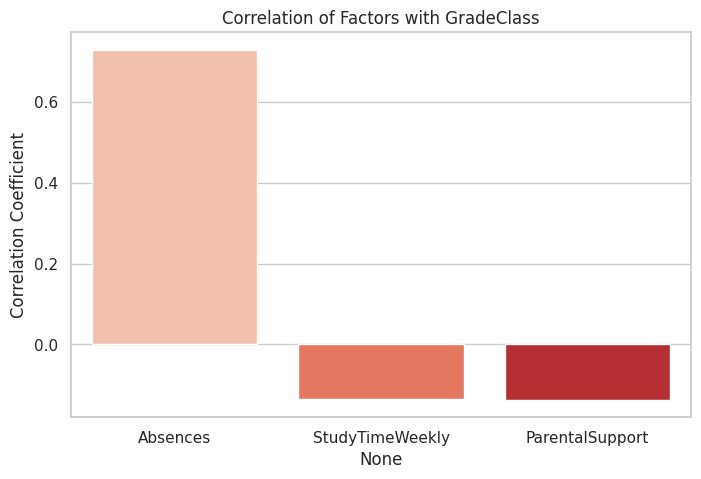

In [ ]:
#@title Correlation of Factors with GradeClass
correlations = df[['Absences', 'StudyTimeWeekly', 'ParentalSupport', 'GradeClass']].corr()['GradeClass'].drop('GradeClass')

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=correlations.index, y=correlations.values, palette='Reds')
plt.title('Correlation of Factors with GradeClass')
plt.ylabel('Correlation Coefficient')
plt.show()

Average study time for GradeClass 4: 9.18 hours
Average study time for GradeClass 3: 9.76 hours


<ipython-input-35-c8b50b5c9c07>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['GradeClass 4', 'GradeClass 3'], y=[study_time_g4, study_time_g3], palette='Blues')


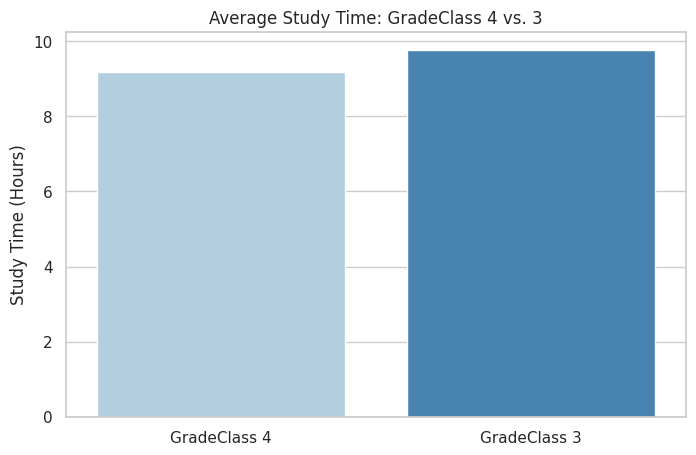

In [ ]:
#@title Average Study Time: GradeClass 4 vs. 3
study_time_g4 = df[df['GradeClass'] == 4]['StudyTimeWeekly'].mean()
study_time_g3 = df[df['GradeClass'] == 3]['StudyTimeWeekly'].mean()

print(f"Average study time for GradeClass 4: {study_time_g4:.2f} hours")
print(f"Average study time for GradeClass 3: {study_time_g3:.2f} hours")

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['GradeClass 4', 'GradeClass 3'], y=[study_time_g4, study_time_g3], palette='Blues')
plt.title('Average Study Time: GradeClass 4 vs. 3')
plt.ylabel('Study Time (Hours)')
plt.show()

<ipython-input-36-0d65ef2177dc>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sports', 'Music', 'Volunteering'], y=[sports_failing, music_failing, volunteering_failing], palette='Set3')


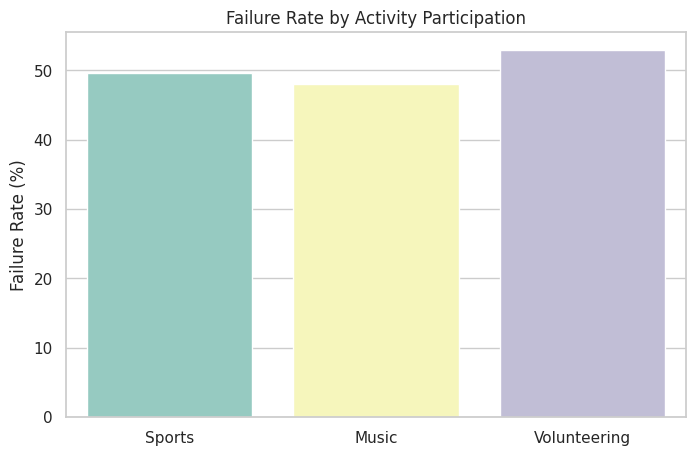

In [ ]:
#@title Failure Rate by Activity Participation
sports_failing = len(df[(df['Sports'] == 1) & (df['GradeClass'] == 4)]) / len(df[df['Sports'] == 1]) * 100
music_failing = len(df[(df['Music'] == 1) & (df['GradeClass'] == 4)]) / len(df[df['Music'] == 1]) * 100
volunteering_failing = len(df[(df['Volunteering'] == 1) & (df['GradeClass'] == 4)]) / len(df[df['Volunteering'] == 1]) * 100

# Visualization: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=['Sports', 'Music', 'Volunteering'], y=[sports_failing, music_failing, volunteering_failing], palette='Set3')
plt.title('Failure Rate by Activity Participation')
plt.ylabel('Failure Rate (%)')
plt.show()

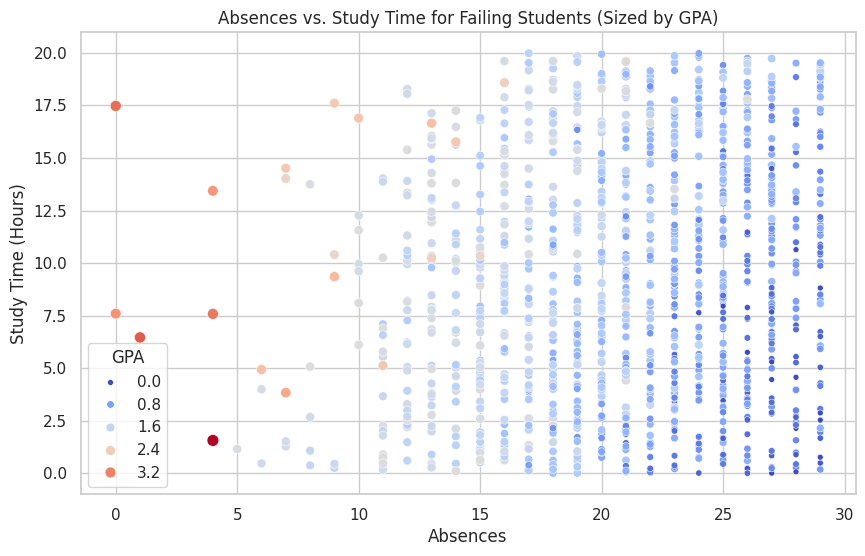

In [ ]:
#@title Absences vs. Study Time for Failing Students (Sized by GPA)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Absences', y='StudyTimeWeekly', size='GPA', hue='GPA', data=df[df['GradeClass'] == 4], palette='coolwarm')
plt.title('Absences vs. Study Time for Failing Students (Sized by GPA)')
plt.xlabel('Absences')
plt.ylabel('Study Time (Hours)')
plt.show()